# SHAP Field-Level Explainability — BERT + XGBoost (BayesSearchCV)\nExplains the actual best model using its real underlying fields (the ones fed into `serialize_row()` before BERT embedding), instead of uninterpretable `bert_pca_#` dimensions.\n\n**Pipeline explained:** raw fields → `serialize_row()` → clean → BERT (mean-pooled) → PCA(20) → spliced into full XGBoost feature vector → prediction.

## 1. Setup

In [17]:
import re, time, json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, make_scorer

RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_COMPONENTS = 20
print("Device:", DEVICE)


Device: cuda


In [18]:
import shap


## 2. Load data

In [19]:
RAW_PATH = r"E:\NSU\cse445\EDA attempt3\Dataset\kickstarter_raw_before_encoding.csv"
TRAIN_PATH = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset\ML_train.csv"
TEST_PATH = r"E:\NSU\cse445\EDA attempt3\Dataset\ML dataset\ML_test.csv"

raw_df   = pd.read_csv(RAW_PATH)
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print("Raw:", raw_df.shape, "| Train:", train_df.shape, "| Test:", test_df.shape)


Raw: (20000, 25) | Train: (16000, 81) | Test: (4000, 81)


## 3. Serialization template (identical to training pipeline)

In [20]:
def serialize_row(row):
    """EXACT copy of the row-to-text template from kickstarter_nlp_embeddings_creation.ipynb"""
    text = (
        f"This Kickstarter project is in the {row['category_parent']} category, "
        f"specifically {row['category_name']}. "
        f"It was launched from {row['location_country']}"
        + (f", {row['location_state']}" if pd.notna(row.get('location_state')) else "")
        + f", with a location type of {row['location_type']}. "
        f"The campaign country is {row['country']} and currency used is {row['currency']}. "
        f"The funding goal was {row['goal_usd']:.2f} USD "
        f"The campaign ran for {row['duration_days']:.1f} days "
        f"with a prelaunch period of {row['prelaunch_days']:.1f} days. "
        f"The project title had {int(row['name_word_count'])} words "
        f"and the blurb had {int(row['blurb_word_count'])} words. "
        f"It was launched in {int(row['launch_month'])}/{int(row['launch_year'])} "
        f"at hour {int(row['launch_hour'])} on weekday {int(row['launch_weekday'])}. "
        f"{'A video was included.' if row['has_video'] == 1 else 'No video was included.'} "
        f"{'Prelaunch marketing was activated.' if row['prelaunch_activated'] == 1 else 'No prelaunch marketing was activated.'}"
    )
    return text

def basic_clean(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s\.]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

SERIALIZE_FIELDS = [
    "category_parent", "category_name", "location_country", "location_state",
    "location_type", "country", "currency", "goal_usd",
    "duration_days", "prelaunch_days", "name_word_count", "blurb_word_count",
    "launch_month", "launch_year", "launch_hour", "launch_weekday",
    "has_video", "prelaunch_activated"
]
NUMERIC_FIELDS = [
    "goal_usd","duration_days","prelaunch_days",
    "name_word_count","blurb_word_count","launch_month","launch_year",
    "launch_hour","launch_weekday","has_video","prelaunch_activated"
]
CATEGORICAL_FIELDS = [f for f in SERIALIZE_FIELDS if f not in NUMERIC_FIELDS]


## 4. BERT embedder

In [21]:
BERT_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(BERT_NAME)
bert_model = AutoModel.from_pretrained(BERT_NAME).to(DEVICE).eval()

@torch.no_grad()
def embed_texts(texts, batch_size=32):
    all_vecs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, padding=True, truncation=True, max_length=128, return_tensors="pt").to(DEVICE)
        out = bert_model(**enc).last_hidden_state
        mask = enc["attention_mask"].unsqueeze(-1).float()
        summed = (out * mask).sum(1)
        counts = mask.sum(1).clamp(min=1e-9)
        mean_pooled = (summed / counts).cpu().numpy()
        all_vecs.append(mean_pooled)
    return np.vstack(all_vecs)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## 5. Rebuild BERT → PCA pipeline (fit PCA on train only, exactly as in training)

In [22]:
raw_df["serialized_text"] = raw_df.apply(serialize_row, axis=1)
raw_df["clean_text"] = raw_df["serialized_text"].apply(basic_clean)

bert_all = embed_texts(raw_df["clean_text"].tolist())
bert_cols = [f"bert_{i}" for i in range(bert_all.shape[1])]
bert_df = pd.DataFrame(bert_all, columns=bert_cols)
bert_df.insert(0, "id", raw_df["id"].values)

train_ids = set(train_df["id"])
train_mask = bert_df["id"].isin(train_ids)

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
pca.fit(bert_df.loc[train_mask, bert_cols])
reduced_all = pca.transform(bert_df[bert_cols])
reduced_cols = [f"bert_pca_{i}" for i in range(N_COMPONENTS)]
reduced_df = pd.DataFrame(reduced_all, columns=reduced_cols)
reduced_df.insert(0, "id", bert_df["id"].values)

print("Explained variance:", pca.explained_variance_ratio_.sum())


Explained variance: 0.74308467


## 6. Build X/y (mirrors `bert_xgb_bayes.ipynb`)

In [23]:
TARGET_LOG = "log_target"
DROP_FROM_X = ["id", "target_usd", "log_target", "goal_usd"]

merged_train = train_df.merge(reduced_df, on="id", how="left")
merged_test  = test_df.merge(reduced_df, on="id", how="left")

X_train = merged_train.drop(columns=DROP_FROM_X, errors="ignore")
X_test  = merged_test.drop(columns=DROP_FROM_X, errors="ignore")
y_train = merged_train[TARGET_LOG].copy()
y_test  = merged_test[TARGET_LOG].copy()

FEATURE_COLS = list(X_train.columns)
assert list(X_train.columns) == list(X_test.columns)
print("X_train:", X_train.shape, "| X_test:", X_test.shape)


X_train: (16000, 97) | X_test: (4000, 97)


## 7. Retrain BERT + XGBoost (BayesSearchCV) — the actual best model

In [24]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_scorer = make_scorer(rmse, greater_is_better=False)
CV = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

xgb_bayes_space = {
    "n_estimators":     Integer(200, 500),
    "learning_rate":    Real(0.01, 0.1, prior="log-uniform"),
    "max_depth":        Integer(4, 9),
    "min_child_weight": Integer(1, 7),
    "subsample":        Real(0.7, 1.0),
    "colsample_bytree": Real(0.7, 1.0),
    "reg_alpha":        Real(1e-3, 0.5, prior="log-uniform"),
    "reg_lambda":       Real(0.5, 3.0),
}

base_estimator = XGBRegressor(
    objective="reg:squarederror", eval_metric="rmse",
    tree_method="hist", device="cuda" if DEVICE == "cuda" else "cpu",
    random_state=RANDOM_STATE,
)

search = BayesSearchCV(
    estimator=base_estimator, search_spaces=xgb_bayes_space, n_iter=4,
    scoring=rmse_scorer, cv=CV, n_jobs=1, random_state=RANDOM_STATE, verbose=0, refit=True,
)
search.fit(X_train, y_train)
best_model = search.best_estimator_
print("Test RMSE_log:", rmse(y_test, best_model.predict(X_test)))


Test RMSE_log: 2.272351056392286


## 8. Align raw serialize_row fields to test rows + background sample

In [25]:
test_ids = merged_test["id"].values
raw_indexed = raw_df.set_index("id")
raw_fields_test = raw_indexed.loc[test_ids, SERIALIZE_FIELDS].reset_index(drop=True)

BG_SIZE = 100
bg_fields = raw_fields_test.sample(BG_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)
print("Test rows:", raw_fields_test.shape, "| Background rows:", bg_fields.shape)


Test rows: (4000, 18) | Background rows: (100, 18)


## 9. End-to-end wrapper: raw fields → serialize → BERT → PCA → full feature vector → predict

In [26]:
def fields_to_full_X(fields_df, base_row):
    """raw fields -> serialize_row -> BERT -> PCA -> spliced into full XGBoost feature vector"""
    texts = fields_df.apply(serialize_row, axis=1).apply(basic_clean).tolist()
    bert_vecs = embed_texts(texts)
    pca_vecs = pca.transform(bert_vecs)

    N = len(fields_df)
    X_out = pd.DataFrame(np.tile(base_row[FEATURE_COLS].values, (N, 1)), columns=FEATURE_COLS)
    for i, c in enumerate(reduced_cols):
        X_out[c] = pca_vecs[:, i]
    return X_out.values

def make_predict_fn(base_row):
    def predict_fn(field_matrix):
        fields_df = pd.DataFrame(field_matrix, columns=SERIALIZE_FIELDS)
        for c in NUMERIC_FIELDS:
            fields_df[c] = pd.to_numeric(fields_df[c])
        X_full = fields_to_full_X(fields_df, base_row)
        return best_model.predict(X_full)
    return predict_fn


## 10. Pick rows to explain

In [27]:
N_EXPLAIN = 20
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(raw_fields_test), N_EXPLAIN, replace=False)
print("Explaining", N_EXPLAIN, "test rows, indices:", sample_idx[:10], "...")


Explaining 20 test rows, indices: [ 555 3491  527 3925 2989   70 1756  211  196  803] ...


## 11. Compute SHAP values (KernelExplainer, field-level)

In [28]:
shap_records = []
for idx in sample_idx:
    base_row = merged_test.iloc[idx]
    instance = raw_fields_test.iloc[[idx]]
    predict_fn = make_predict_fn(base_row)

    explainer = shap.KernelExplainer(predict_fn, bg_fields.values, feature_names=SERIALIZE_FIELDS)
    sv = explainer.shap_values(instance.values, nsamples=100)
    shap_records.append(sv[0])
    print(f"Row {idx} done")

shap_matrix = np.array(shap_records)  # (N_EXPLAIN, num_fields)
shap_df = pd.DataFrame(shap_matrix, columns=SERIALIZE_FIELDS)
shap_df.to_csv("bert_xgb_field_shap_values.csv", index=False)
print("Saved bert_xgb_field_shap_values.csv", shap_df.shape)


  0%|          | 0/1 [00:00<?, ?it/s]

Row 555 done


  0%|          | 0/1 [00:00<?, ?it/s]

Row 3491 done


  0%|          | 0/1 [00:00<?, ?it/s]

...

Row 471 done


  0%|          | 0/1 [00:00<?, ?it/s]

Row 594 done


  0%|          | 0/1 [00:00<?, ?it/s]

Row 321 done
Saved bert_xgb_field_shap_values.csv (20, 18)


## 12. Graph 1 — Beeswarm summary (impact + direction per field)

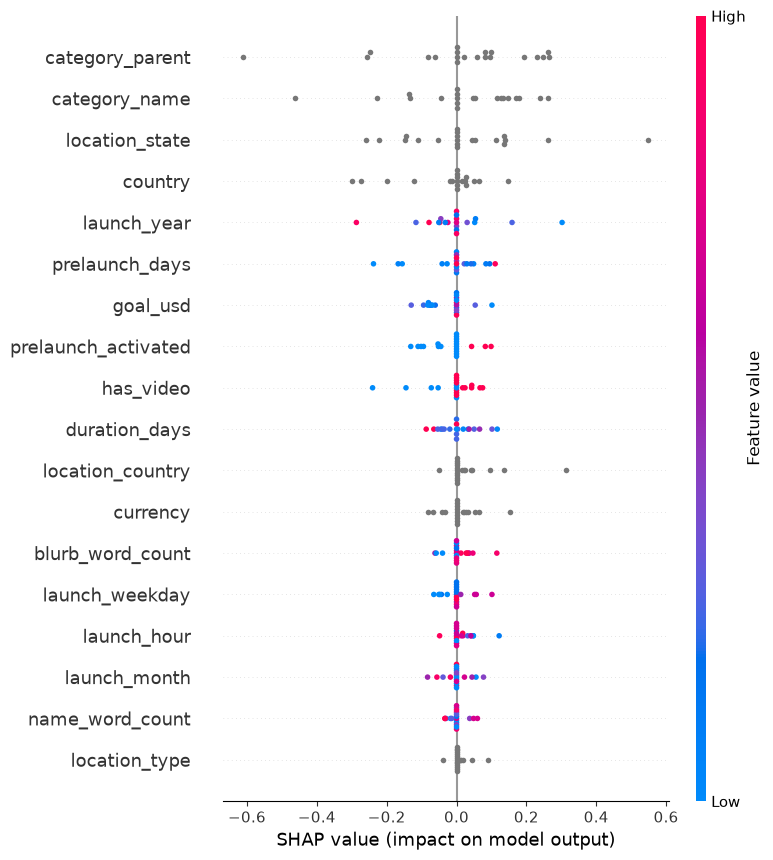

In [29]:
# Graph 1: Beeswarm summary plot (impact + direction per field, across all explained rows)
plt.figure()
shap.summary_plot(
    shap_matrix,
    raw_fields_test.iloc[sample_idx],
    feature_names=SERIALIZE_FIELDS,
    show=False
)
plt.tight_layout()
plt.savefig("shap_beeswarm_summary.png", dpi=150, bbox_inches="tight")
plt.show()


## 13. Graph 2 — Bar chart (global field importance ranking)

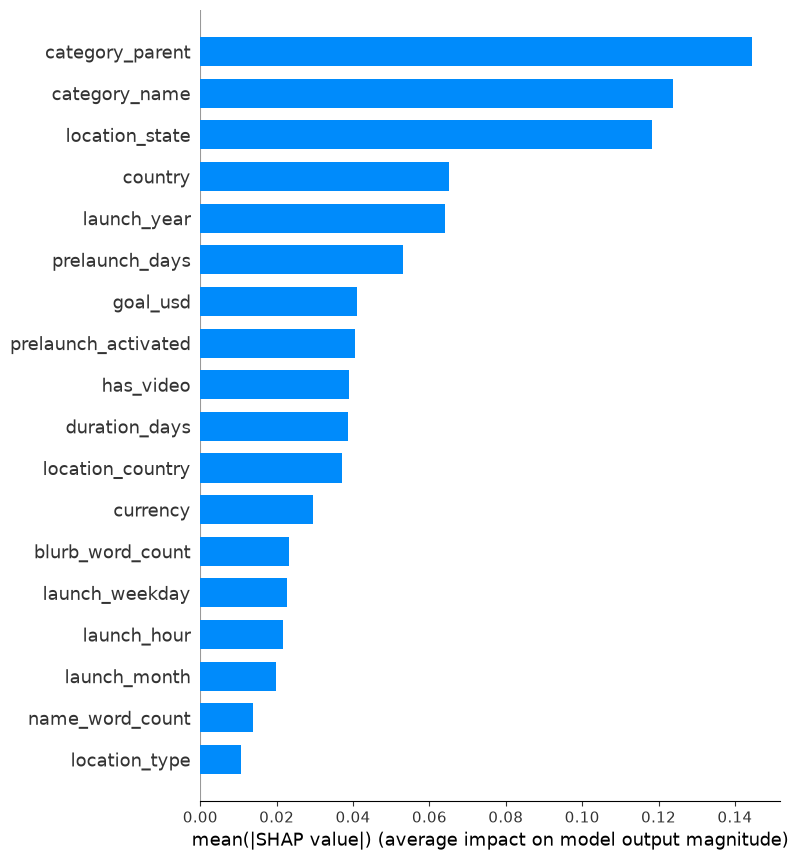

In [30]:
# Graph 2: Bar plot (mean absolute SHAP value per field = global importance ranking)
plt.figure()
shap.summary_plot(
    shap_matrix,
    raw_fields_test.iloc[sample_idx],
    feature_names=SERIALIZE_FIELDS,
    plot_type="bar",
    show=False
)
plt.tight_layout()
plt.savefig("shap_bar_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 14. Graph 3 — Waterfall (single-instance local explanation)

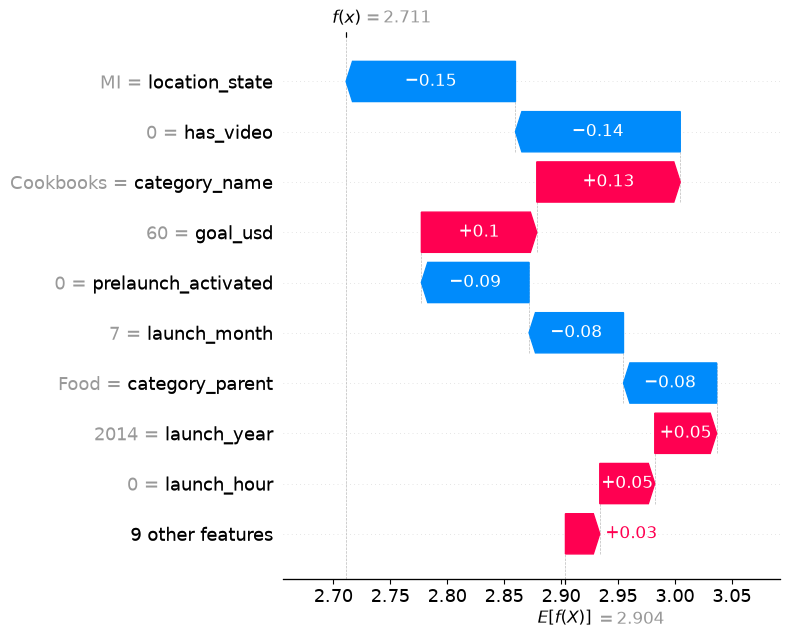

In [31]:
# Graph 3: Waterfall plot for a single representative instance (local explanation)
example_i = 0  # index into sample_idx / shap_matrix
explanation = shap.Explanation(
    values=shap_matrix[example_i],
    base_values=np.mean([best_model.predict(fields_to_full_X(bg_fields, merged_test.iloc[sample_idx[example_i]]))]),
    data=raw_fields_test.iloc[sample_idx[example_i]].values,
    feature_names=SERIALIZE_FIELDS
)
plt.figure()
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.savefig("shap_waterfall_single_instance.png", dpi=150, bbox_inches="tight")
plt.show()


## 15. Graph 4 — Heatmap (all explained instances × fields)

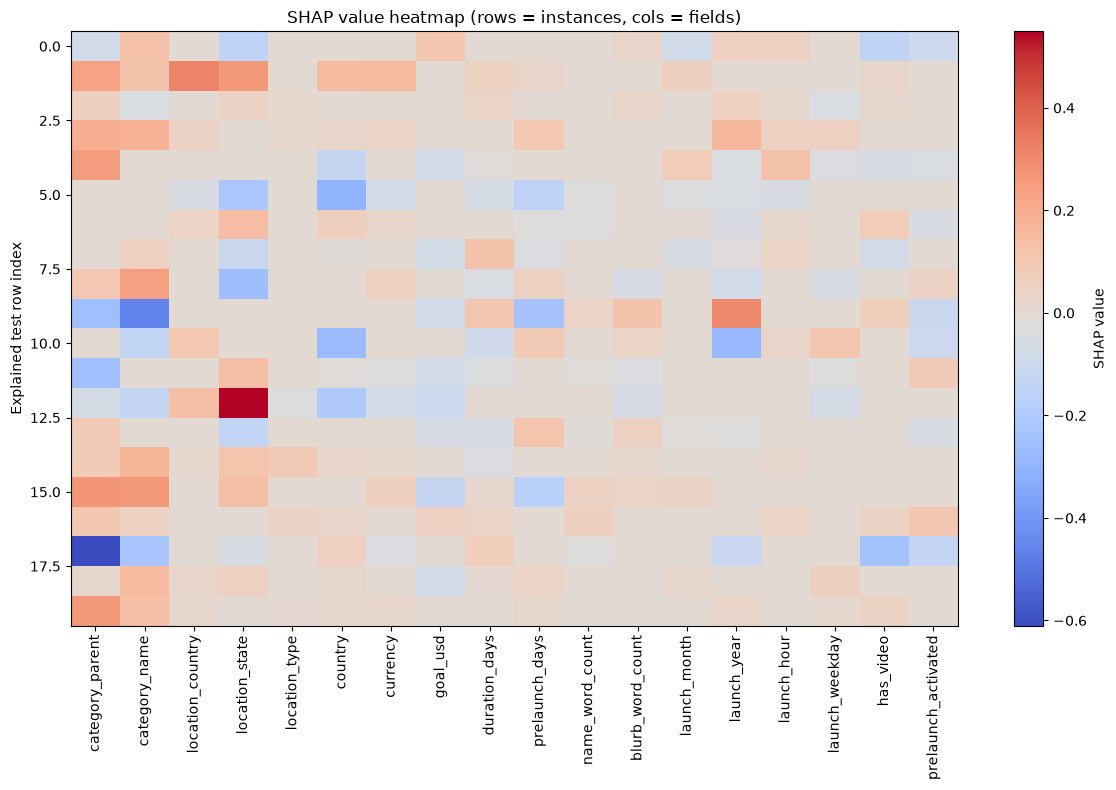

In [32]:
# Graph 4: Heatmap of SHAP values across all explained instances x fields
plt.figure(figsize=(12, 8))
plt.imshow(shap_matrix, aspect="auto", cmap="coolwarm")
plt.colorbar(label="SHAP value")
plt.xticks(range(len(SERIALIZE_FIELDS)), SERIALIZE_FIELDS, rotation=90)
plt.ylabel("Explained test row index")
plt.title("SHAP value heatmap (rows = instances, cols = fields)")
plt.tight_layout()
plt.savefig("shap_heatmap_instances_fields.png", dpi=150, bbox_inches="tight")
plt.show()


## Outputs\n- `bert_xgb_field_shap_values.csv`\n- `shap_beeswarm_summary.png`\n- `shap_bar_importance.png`\n- `shap_waterfall_single_instance.png`\n- `shap_heatmap_instances_fields.png`

In [33]:
mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)
mean_abs_shap.to_csv("bert_xgb_field_shap_mean_abs.csv", header=["mean_abs_shap"])
print(mean_abs_shap)

category_parent        0.144570
category_name          0.123849
location_state         0.118388
country                0.065036
launch_year            0.064033
prelaunch_days         0.053038
goal_usd               0.041086
prelaunch_activated    0.040572
has_video              0.039033
duration_days          0.038624
location_country       0.037135
currency               0.029510
blurb_word_count       0.023129
launch_weekday         0.022776
launch_hour            0.021554
launch_month           0.019770
name_word_count        0.013697
location_type          0.010564
dtype: float64
